# Long-Run

In [1]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.colors as mcolors
#
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit

In [2]:
path = {'coords' : '/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc',
'mask' : '/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc',
'bathy' : '/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc'
}
#
coords = xr.open_dataset(path['coords'], decode_times=False)
mask = xr.open_dataset(path['mask'])
bathy = xr.open_dataset(path['bathy'])

In [3]:
from Regions_functions_V2 import polygon_N1, polygon_lon_lat_N1, polygon_S1, polygon_lon_lat_S1, polygon_H1, polygon_lon_lat_H1

In [4]:
def get_total_timeseries_optimized(filename, polygon_coords, 
                                  lon_var='lon', lat_var='lat', status_var='status', 
                                  target_status=2, chunk_size=500):
    """
    Computes a particle timeseries filtered by status and polygon containment.
    Optimized for minimal memory usage and high execution speed via chunking.
    """
    poly_path = Path(polygon_coords)
    
    with xr.open_dataset(filename) as data:
        n_obs = data.sizes['obs'] 
        counts_per_time = np.zeros(n_obs, dtype=int)
        
        for start in range(0, n_obs, chunk_size):
            end = min(start + chunk_size, n_obs)
            
            status_chunk = data[status_var].isel(obs=slice(start, end)).values
            
            if isinstance(target_status, (list, tuple, np.ndarray)):
                status_mask = np.isin(status_chunk, target_status)
            else:
                status_mask = (status_chunk == target_status)
            
            if not np.any(status_mask):
                continue
                

            lon_chunk = data[lon_var].isel(obs=slice(start, end)).values[status_mask]
            lat_chunk = data[lat_var].isel(obs=slice(start, end)).values[status_mask]
            
            points = np.column_stack((lon_chunk, lat_chunk))
            inside_poly = poly_path.contains_points(points)
            
            if np.any(inside_poly):

                chunk_time_indices = np.where(status_mask)[1]
                absolute_time_indices = chunk_time_indices[inside_poly] + start
                
                counts_per_time += np.bincount(absolute_time_indices, minlength=n_obs)
                
    return pd.DataFrame({'Total_Count': counts_per_time})

In [5]:
def finder2(target_lat, target_lon,mask=mask):
# Load grid data (e.g., from a NetCDF file)
    lat = mask.nav_lat
    lon = mask.nav_lon
    #find closest grid
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

# At Region S1

In [6]:
filename_y1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_1.nc'
filename_y2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_2.nc'
filename_y3 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_3.nc'
filename_y4 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_4.nc'
filename_y5 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_5.nc'
filename_y6 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_6.nc'
filename_y7 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_7.nc'
filename_y8 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_8.nc'

In [7]:
#data1 = xr.open_dataset(filename_y1)
#data2 = xr.open_dataset(filename_y2)

In [8]:
tseries_y1 = get_total_timeseries_optimized(filename_y1, polygon_lon_lat_S1)
tseries_y2 = get_total_timeseries_optimized(filename_y2, polygon_lon_lat_S1)
tseries_y3 = get_total_timeseries_optimized(filename_y3, polygon_lon_lat_S1)
tseries_y4 = get_total_timeseries_optimized(filename_y4, polygon_lon_lat_S1)
tseries_y5 = get_total_timeseries_optimized(filename_y5, polygon_lon_lat_S1)
tseries_y6 = get_total_timeseries_optimized(filename_y6, polygon_lon_lat_S1)
tseries_y7 = get_total_timeseries_optimized(filename_y7, polygon_lon_lat_S1)
tseries_y8 = get_total_timeseries_optimized(filename_y8, polygon_lon_lat_S1)

In [9]:
values_y1 = tseries_y1['Total_Count'].values[::2]
values_y2 = values_y1 + tseries_y2['Total_Count'].values[::2]
values_y3 = values_y2 + tseries_y3['Total_Count'].values
values_y4 = values_y3 + tseries_y4['Total_Count'].values
values_y5 = values_y4 + tseries_y5['Total_Count'].values
values_y6 = values_y5 + tseries_y6['Total_Count'].values
values_y7 = values_y6 + tseries_y7['Total_Count'].values
values_y8 = values_y7 + tseries_y8['Total_Count'].values

In [10]:
tseries_y1_N = get_total_timeseries_optimized(filename_y1, polygon_lon_lat_N1)
tseries_y2_N = get_total_timeseries_optimized(filename_y2, polygon_lon_lat_N1)
tseries_y3_N = get_total_timeseries_optimized(filename_y3, polygon_lon_lat_N1)
tseries_y4_N = get_total_timeseries_optimized(filename_y4, polygon_lon_lat_N1)
tseries_y5_N = get_total_timeseries_optimized(filename_y5, polygon_lon_lat_N1)
tseries_y6_N = get_total_timeseries_optimized(filename_y6, polygon_lon_lat_N1)
tseries_y7_N = get_total_timeseries_optimized(filename_y7, polygon_lon_lat_N1)
tseries_y8_N = get_total_timeseries_optimized(filename_y8, polygon_lon_lat_N1)

In [11]:
values_y1_N = tseries_y1_N['Total_Count'].values[::2]
values_y2_N = values_y1_N + tseries_y2_N['Total_Count'].values[::2]
values_y3_N = values_y2_N + tseries_y3_N['Total_Count'].values
values_y4_N = values_y3_N + tseries_y4_N['Total_Count'].values
values_y5_N = values_y4_N + tseries_y5_N['Total_Count'].values
values_y6_N = values_y5_N + tseries_y6_N['Total_Count'].values
values_y7_N = values_y6_N + tseries_y7_N['Total_Count'].values
values_y8_N = values_y7_N + tseries_y8_N['Total_Count'].values

In [12]:
tseries_y1_H = get_total_timeseries_optimized(filename_y1, polygon_lon_lat_H1)
tseries_y2_H = get_total_timeseries_optimized(filename_y2, polygon_lon_lat_H1)
tseries_y3_H = get_total_timeseries_optimized(filename_y3, polygon_lon_lat_H1)
tseries_y4_H = get_total_timeseries_optimized(filename_y4, polygon_lon_lat_H1)
tseries_y5_H = get_total_timeseries_optimized(filename_y5, polygon_lon_lat_H1)
tseries_y6_H = get_total_timeseries_optimized(filename_y6, polygon_lon_lat_H1)
tseries_y7_H = get_total_timeseries_optimized(filename_y7, polygon_lon_lat_H1)
tseries_y8_H = get_total_timeseries_optimized(filename_y8, polygon_lon_lat_H1)

In [13]:
values_y1_H = tseries_y1_H['Total_Count'].values[::2]
values_y2_H = values_y1_H + tseries_y2_H['Total_Count'].values[::2]
values_y3_H = values_y2_H + tseries_y3_H['Total_Count'].values
values_y4_H = values_y3_H + tseries_y4_H['Total_Count'].values
values_y5_H = values_y4_H + tseries_y5_H['Total_Count'].values
values_y6_H = values_y5_H + tseries_y6_H['Total_Count'].values
values_y7_H = values_y6_H + tseries_y7_H['Total_Count'].values
values_y8_H = values_y7_H + tseries_y8_H['Total_Count'].values

In [14]:
total_timeseries = np.concatenate([values_y1, values_y2, values_y3, values_y4, values_y5, values_y6, values_y7, values_y8])
total_timeseries_N = np.concatenate([values_y1_N, values_y2_N, values_y3_N, values_y4_N, values_y5_N, values_y6_N, values_y7_N, values_y8_N])
total_timeseries_H = np.concatenate([values_y1_H, values_y2_H, values_y3_H, values_y4_H, values_y5_H, values_y6_H, values_y7_H, values_y8_H])
time_6h = pd.date_range(start='2007-01-01', periods=1460*8, freq='6h')

/tmp/ipykernel_1596192/1188480788.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.plot(time_6h, total_timeseries/total_timeseries_N, 'k')
/tmp/ipykernel_1596192/1188480788.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(time_6h, total_timeseries/total_timeseries_N, 'k')


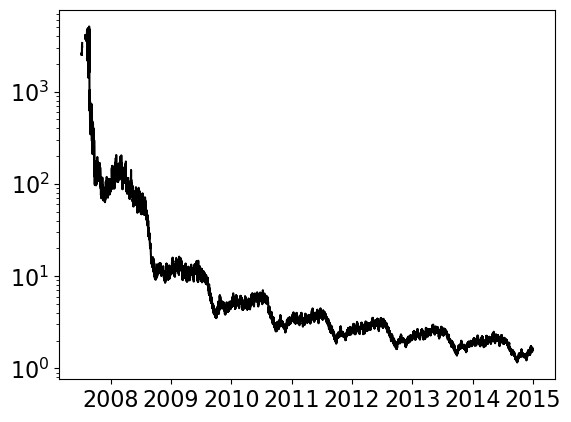

In [30]:
plt.plot(time_6h, total_timeseries/total_timeseries_N, 'k')
plt.yscale('log')

/tmp/ipykernel_1596192/710622401.py:12: RuntimeWarning: divide by zero encountered in divide
  axis1.plot(time_6h, total_timeseries/total_timeseries_N, 'k', alpha = .5, label = 'Ratio S1/N1')
/tmp/ipykernel_1596192/710622401.py:12: RuntimeWarning: invalid value encountered in divide
  axis1.plot(time_6h, total_timeseries/total_timeseries_N, 'k', alpha = .5, label = 'Ratio S1/N1')


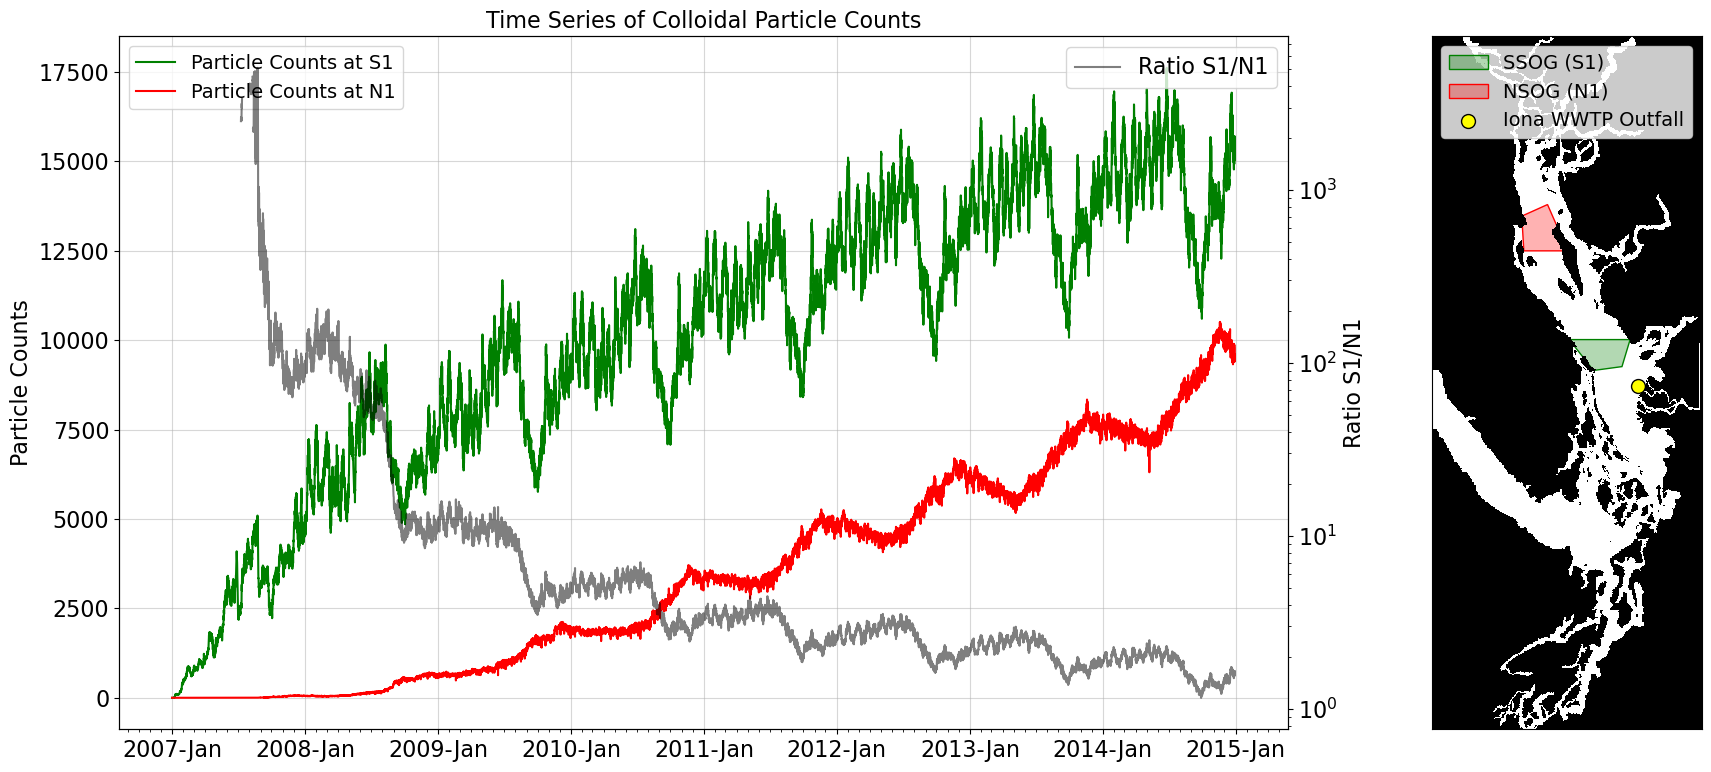

In [37]:
import matplotlib.dates as mdates

plt.rcParams.update({'font.size': 16})
colors = [(0, 0, 0, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(18, 8), gridspec_kw={'width_ratios': [3, 1]})

ax1.plot(time_6h, total_timeseries, 'g', label='Particle Counts at S1') 
ax1.plot(time_6h, total_timeseries_N, 'r', label='Particle Counts at N1') 
axis1 = ax1.twinx()
axis1.plot(time_6h, total_timeseries/total_timeseries_N, 'k', alpha = .5, label = 'Ratio S1/N1')
axis1.set_yscale('log')
axis1.set_ylabel('Ratio S1/N1')
axis1.legend(loc = 'upper right')
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
ax1.xaxis.set_minor_locator(mdates.MonthLocator(interval=1)) 
ax1.grid(True, alpha=0.5)
ax1.legend(fontsize=14, loc = 'upper left')
ax1.set_ylabel('Particle Counts')
ax1.set_title('Time Series of Colloidal Particle Counts', fontsize = 16)
#
plot_polygon(polygon_S1, ax=ax2, color='g', label = 'SSOG (S1)',add_points=False)
plot_polygon(polygon_N1, ax=ax2, color='r', label = 'NSOG (N1)',add_points=False)
#plot_polygon(polygon_S1, ax=ax2, color='g', label = 'SSOG (S1)',add_points=False)

ax2.pcolormesh(mask['tmask'][0][0], cmap = cmap)
## Source ##
source_lat = 49.195045
source_lon = -123.301956
s_y, s_x = finder2(source_lat, source_lon, mask)
s_y, s_x = finder2(source_lat, source_lon, mask)
##
ax2.scatter(s_x, s_y, color='yellow', edgecolor='black', s=100, zorder=5, label='Iona WWTP Outfall')
ax2.tick_params(which='both', bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False)
f = 1.14
ax2.set_aspect(f); ax2.legend(loc = 'upper right', fontsize = 14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Fitted Parameters:
Amplitude (a): -15193.88
Rate per day (b): -0.00074
Offset (c): 16236.32


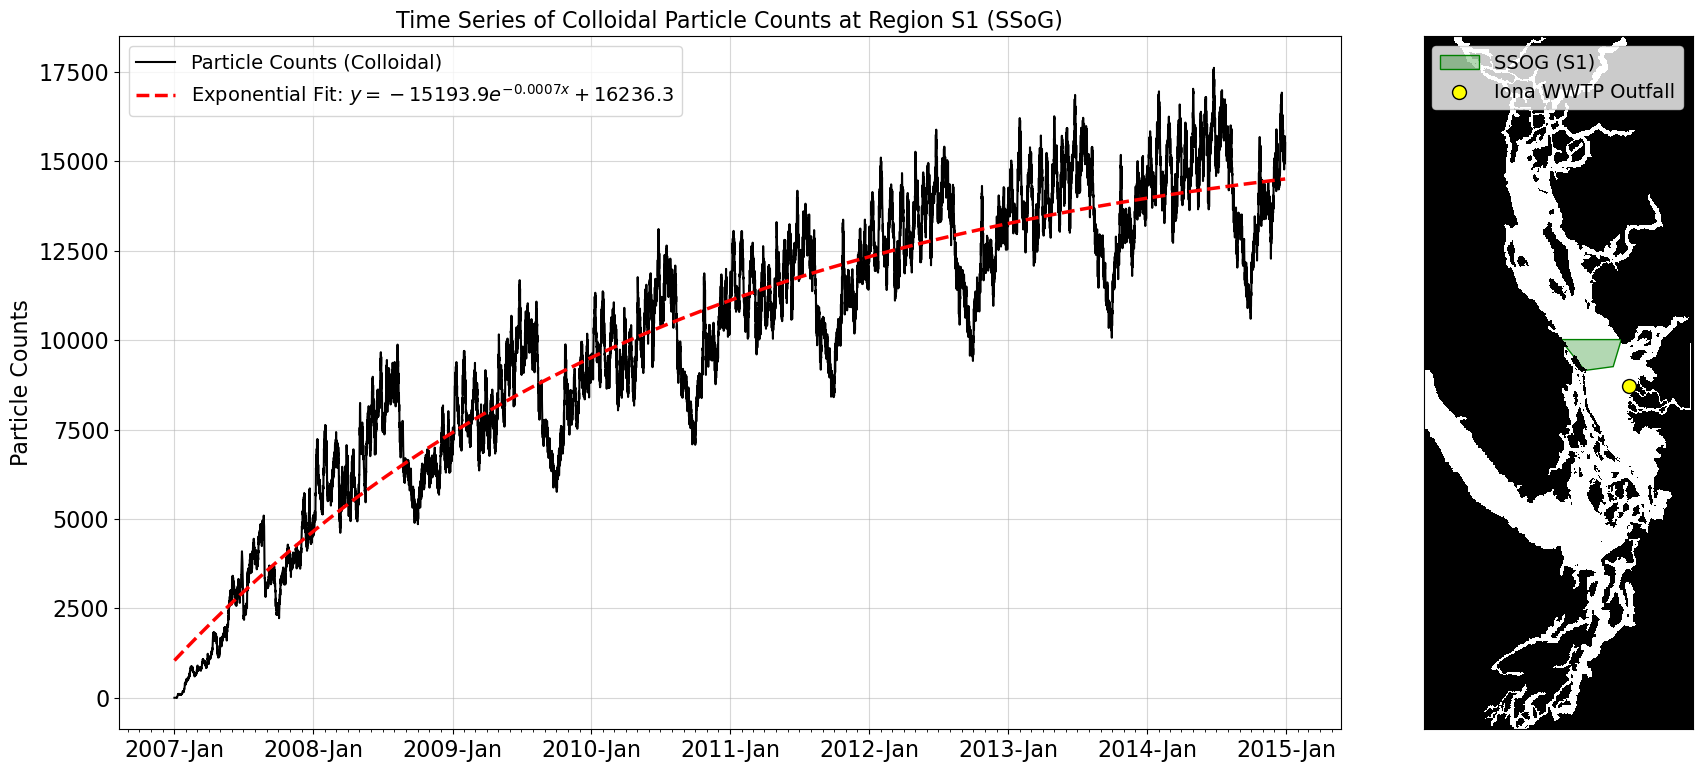

In [13]:
import matplotlib.dates as mdates
from scipy.optimize import curve_fit

def exponential_func(x, a, b, c):
    return a * np.exp(b * x) + c



x_days = np.arange(len(total_timeseries)) / 4.0


initial_guess = [np.max(total_timeseries) - np.min(total_timeseries), -0.01, np.min(total_timeseries)]

popt, pcov = curve_fit(exponential_func, x_days, total_timeseries, p0=initial_guess, maxfev=10000)

a_fit, b_fit, c_fit = popt
print(f"Fitted Parameters:")
print(f"Amplitude (a): {a_fit:.2f}")
print(f"Rate per day (b): {b_fit:.5f}")
print(f"Offset (c): {c_fit:.2f}")

fitted_curve = exponential_func(x_days, a_fit, b_fit, c_fit)

plt.rcParams.update({'font.size': 16})
colors = [(0, 0, 0, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(18, 8), gridspec_kw={'width_ratios': [3, 1]})

ax1.plot(time_6h, total_timeseries, 'k', label='Particle Counts (Colloidal)') 

ax1.plot(time_6h, fitted_curve, 'r--', linewidth=2.5, 
        label=f'Exponential Fit: $y = {a_fit:.1f}e^{{{b_fit:.4f}x}} + {c_fit:.1f}$')

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
ax1.xaxis.set_minor_locator(mdates.MonthLocator(interval=1)) 
ax1.grid(True, alpha=0.5)
ax1.legend(fontsize=14, loc = 'upper left')
ax1.set_ylabel('Particle Counts')
ax1.set_title('Time Series of Colloidal Particle Counts at Region S1 (SSoG)', fontsize = 16)
#
plot_polygon(polygon_S1, ax=ax2, color='g', label = 'SSOG (S1)',add_points=False)
#ax3.scatter(points_x_N2, points_y_N2, c = colors_regions[6],s = 20,  marker = 's')
#ax3.scatter(points_x_N3, points_y_N3, c = colors_regions[6],s = 20,  marker = 's')

ax2.pcolormesh(mask['tmask'][0][0], cmap = cmap)
## Source ##
source_lat = 49.195045
source_lon = -123.301956
s_y, s_x = finder2(source_lat, source_lon, mask)
s_y, s_x = finder2(source_lat, source_lon, mask)
##
ax2.scatter(s_x, s_y, color='yellow', edgecolor='black', s=100, zorder=5, label='Iona WWTP Outfall')
ax2.tick_params(which='both', bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False)
f = 1.14
ax2.set_aspect(f); ax2.legend(loc = 'upper right', fontsize = 14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Fitted Parameters:
Amplitude (a): -5.19
Rate per day (b): -0.00110
Offset (c): 4.52


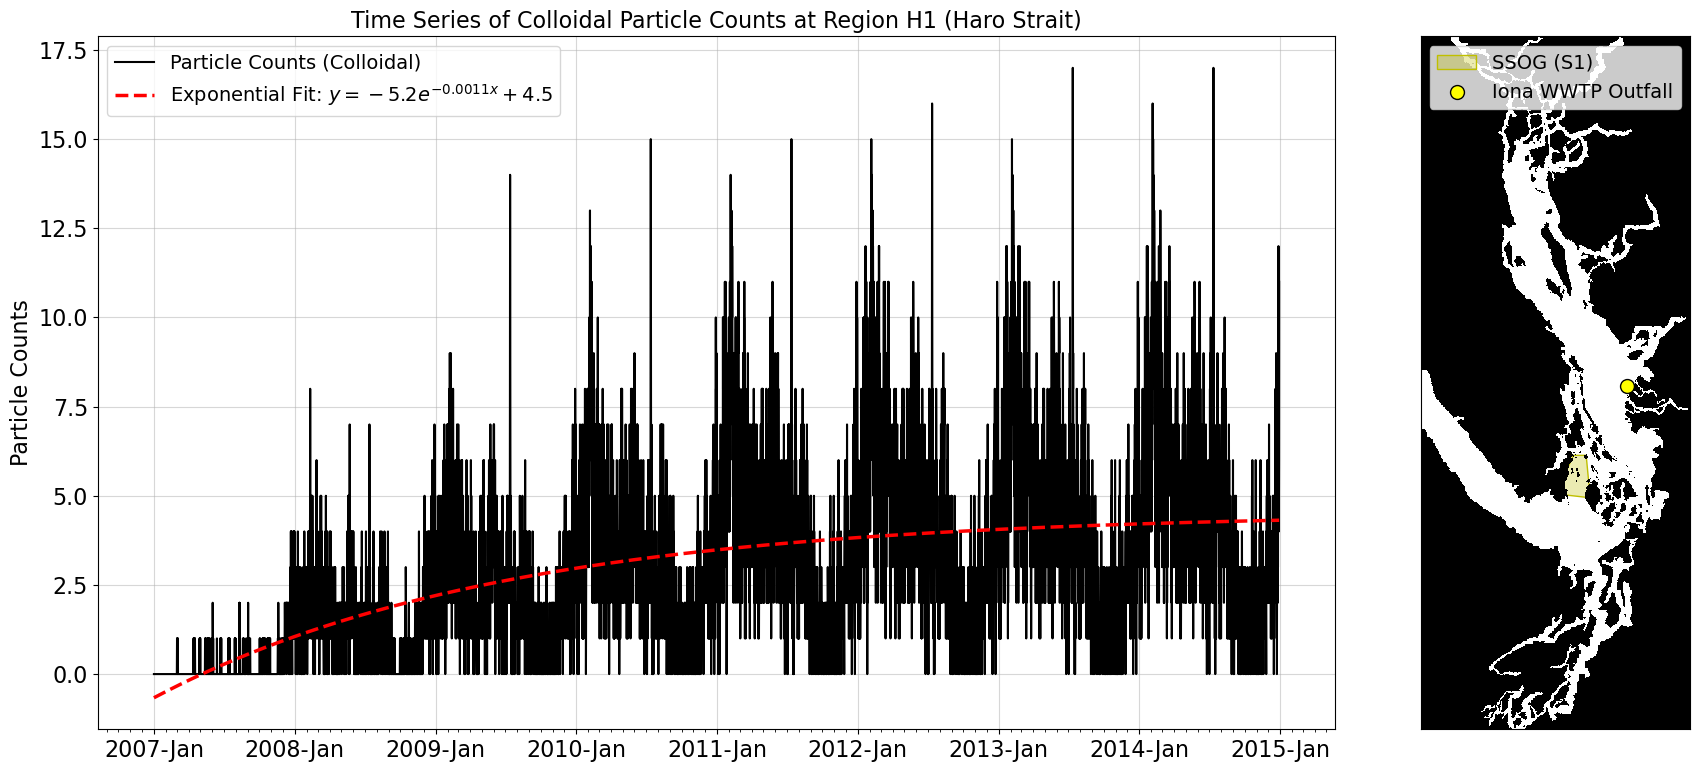

In [14]:
import matplotlib.dates as mdates
from scipy.optimize import curve_fit

def exponential_func(x, a, b, c):
    return a * np.exp(b * x) + c



x_days = np.arange(len(total_timeseries_H)) / 4.0


initial_guess = [np.max(total_timeseries_H) - np.min(total_timeseries_H), -0.01, np.min(total_timeseries_H)]

popt, pcov = curve_fit(exponential_func, x_days, total_timeseries_H, p0=initial_guess, maxfev=10000)

a_fit, b_fit, c_fit = popt
print(f"Fitted Parameters:")
print(f"Amplitude (a): {a_fit:.2f}")
print(f"Rate per day (b): {b_fit:.5f}")
print(f"Offset (c): {c_fit:.2f}")

fitted_curve = exponential_func(x_days, a_fit, b_fit, c_fit)

plt.rcParams.update({'font.size': 16})
colors = [(0, 0, 0, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(18, 8), gridspec_kw={'width_ratios': [3, 1]})

ax1.plot(time_6h, total_timeseries_H, 'k', label='Particle Counts (Colloidal)') 

ax1.plot(time_6h, fitted_curve, 'r--', linewidth=2.5, 
        label=f'Exponential Fit: $y = {a_fit:.1f}e^{{{b_fit:.4f}x}} + {c_fit:.1f}$')

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
ax1.xaxis.set_minor_locator(mdates.MonthLocator(interval=1)) 
ax1.grid(True, alpha=0.5)
ax1.legend(fontsize=14, loc = 'upper left')
ax1.set_ylabel('Particle Counts')
ax1.set_title('Time Series of Colloidal Particle Counts at Region H1 (Haro Strait)', fontsize = 16)
#
plot_polygon(polygon_H1, ax=ax2, color='y', label = 'SSOG (S1)',add_points=False)
#ax3.scatter(points_x_N2, points_y_N2, c = colors_regions[6],s = 20,  marker = 's')
#ax3.scatter(points_x_N3, points_y_N3, c = colors_regions[6],s = 20,  marker = 's')

ax2.pcolormesh(mask['tmask'][0][0], cmap = cmap)
## Source ##
source_lat = 49.195045
source_lon = -123.301956
s_y, s_x = finder2(source_lat, source_lon, mask)
s_y, s_x = finder2(source_lat, source_lon, mask)
##
ax2.scatter(s_x, s_y, color='yellow', edgecolor='black', s=100, zorder=5, label='Iona WWTP Outfall')
ax2.tick_params(which='both', bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False)
f = 1.14
ax2.set_aspect(f); ax2.legend(loc = 'upper right', fontsize = 14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

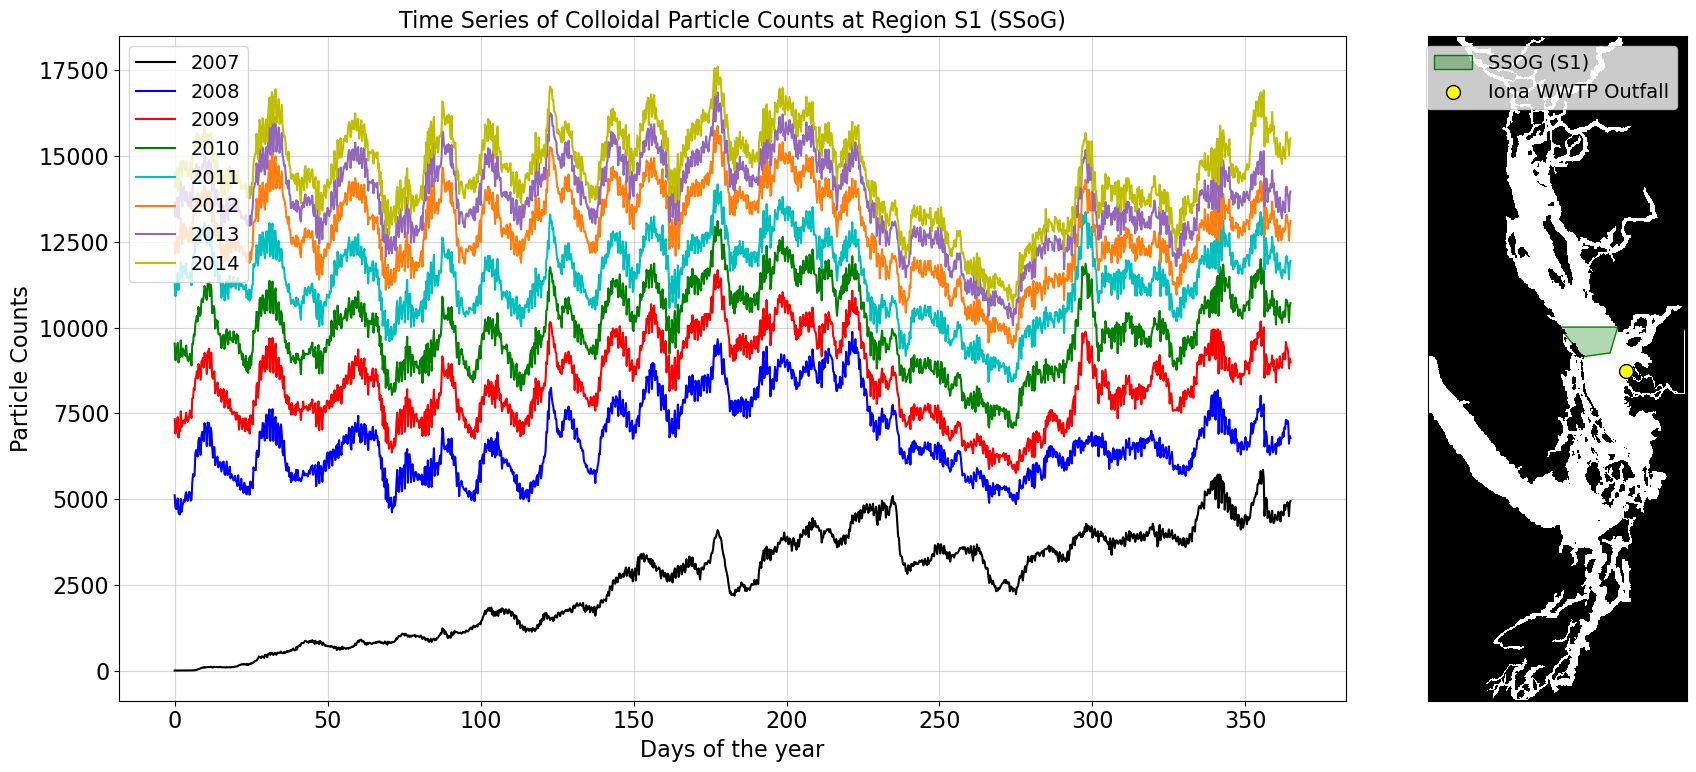

In [17]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(18, 8), gridspec_kw={'width_ratios': [3, 1]})
time_days = np.arange(1460) * 0.25
ax1.plot(time_days, values_y1, 'k', label='2007') 
ax1.plot(time_days, values_y2, 'b', label='2008') 
ax1.plot(time_days, values_y3, 'r', label='2009') 
ax1.plot(time_days, values_y4, 'g', label='2010') 
ax1.plot(time_days, values_y5, 'c', label='2011') 
ax1.plot(time_days, values_y6, 'tab:orange', label='2012') 
ax1.plot(time_days, values_y7, 'tab:purple', label='2013') 
ax1.plot(time_days, values_y8, 'y', label='2014') 

#ax1.xaxis.set_major_locator(mdates.YearLocator())
#ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
#ax1.xaxis.set_minor_locator(mdates.MonthLocator(interval=1)) 
ax1.grid(True, alpha=0.5)
ax1.legend(fontsize=14, loc = 'upper left')
ax1.set_ylabel('Particle Counts')
ax1.set_title('Time Series of Colloidal Particle Counts at Region S1 (SSoG)', fontsize = 16)
ax1.set_xlabel('Days of the year')
#
plot_polygon(polygon_S1, ax=ax2, color='g', label = 'SSOG (S1)',add_points=False)
#ax3.scatter(points_x_N2, points_y_N2, c = colors_regions[6],s = 20,  marker = 's')
#ax3.scatter(points_x_N3, points_y_N3, c = colors_regions[6],s = 20,  marker = 's')

ax2.pcolormesh(mask['tmask'][0][0], cmap = cmap)
## Source ##
source_lat = 49.195045
source_lon = -123.301956
s_y, s_x = finder2(source_lat, source_lon, mask)
s_y, s_x = finder2(source_lat, source_lon, mask)
##
ax2.scatter(s_x, s_y, color='yellow', edgecolor='black', s=100, zorder=5, label='Iona WWTP Outfall')
ax2.tick_params(which='both', bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False)
f = 1.14
ax2.set_aspect(f); ax2.legend(loc = 'upper right', fontsize = 14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

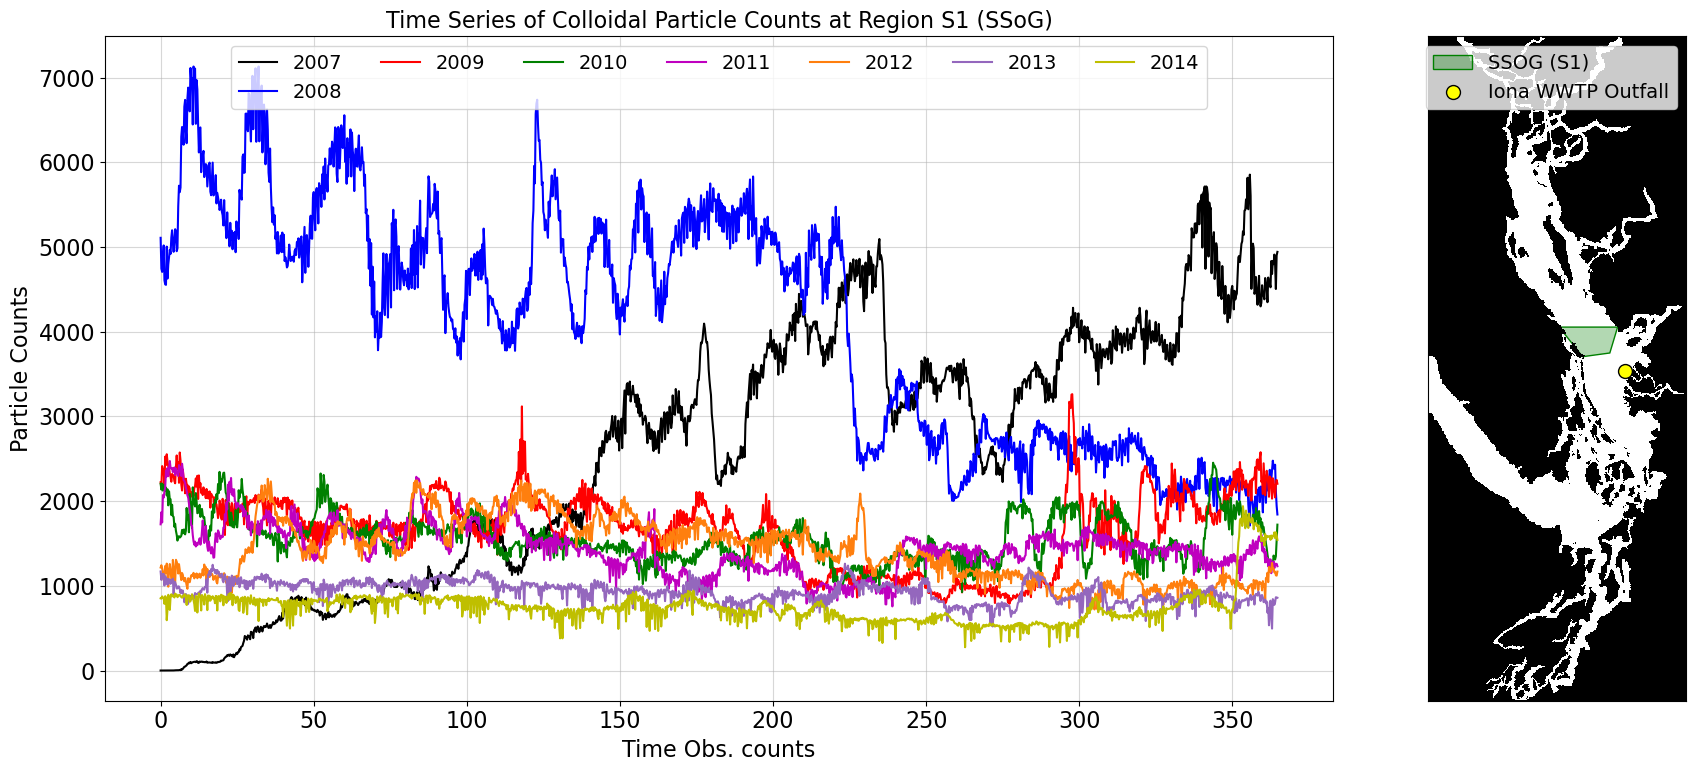

In [18]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(18, 8), gridspec_kw={'width_ratios': [3, 1]})

ax1.plot(time_days, tseries_y1['Total_Count'].values[::2], 'k', label='2007') 
ax1.plot(time_days, tseries_y2['Total_Count'].values[::2], 'b', label='2008') 
ax1.plot(time_days, tseries_y3['Total_Count'], 'r', label='2009') 
ax1.plot(time_days, tseries_y4['Total_Count'], 'g', label='2010') 
ax1.plot(time_days, tseries_y5['Total_Count'], 'm', label='2011') 
ax1.plot(time_days, tseries_y6['Total_Count'], 'tab:orange', label='2012') 
ax1.plot(time_days, tseries_y7['Total_Count'], 'tab:purple', label='2013') 
ax1.plot(time_days, tseries_y8['Total_Count'], 'y', label='2014') 


#ax1.xaxis.set_major_locator(mdates.YearLocator())
#ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
#ax1.xaxis.set_minor_locator(mdates.MonthLocator(interval=1)) 
ax1.grid(True, alpha=0.5)
ax1.legend(fontsize=14, loc = 'upper center', ncol = 7)
ax1.set_ylabel('Particle Counts')
ax1.set_title('Time Series of Colloidal Particle Counts at Region S1 (SSoG)', fontsize = 16)
ax1.set_xlabel('Time Obs. counts')
#
plot_polygon(polygon_S1, ax=ax2, color='g', label = 'SSOG (S1)',add_points=False)
#ax3.scatter(points_x_N2, points_y_N2, c = colors_regions[6],s = 20,  marker = 's')
#ax3.scatter(points_x_N3, points_y_N3, c = colors_regions[6],s = 20,  marker = 's')

ax2.pcolormesh(mask['tmask'][0][0], cmap = cmap)
## Source ##
source_lat = 49.195045
source_lon = -123.301956
s_y, s_x = finder2(source_lat, source_lon, mask)
s_y, s_x = finder2(source_lat, source_lon, mask)
##
ax2.scatter(s_x, s_y, color='yellow', edgecolor='black', s=100, zorder=5, label='Iona WWTP Outfall')
ax2.tick_params(which='both', bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False)
f = 1.14
ax2.set_aspect(f); ax2.legend(loc = 'upper right', fontsize = 14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

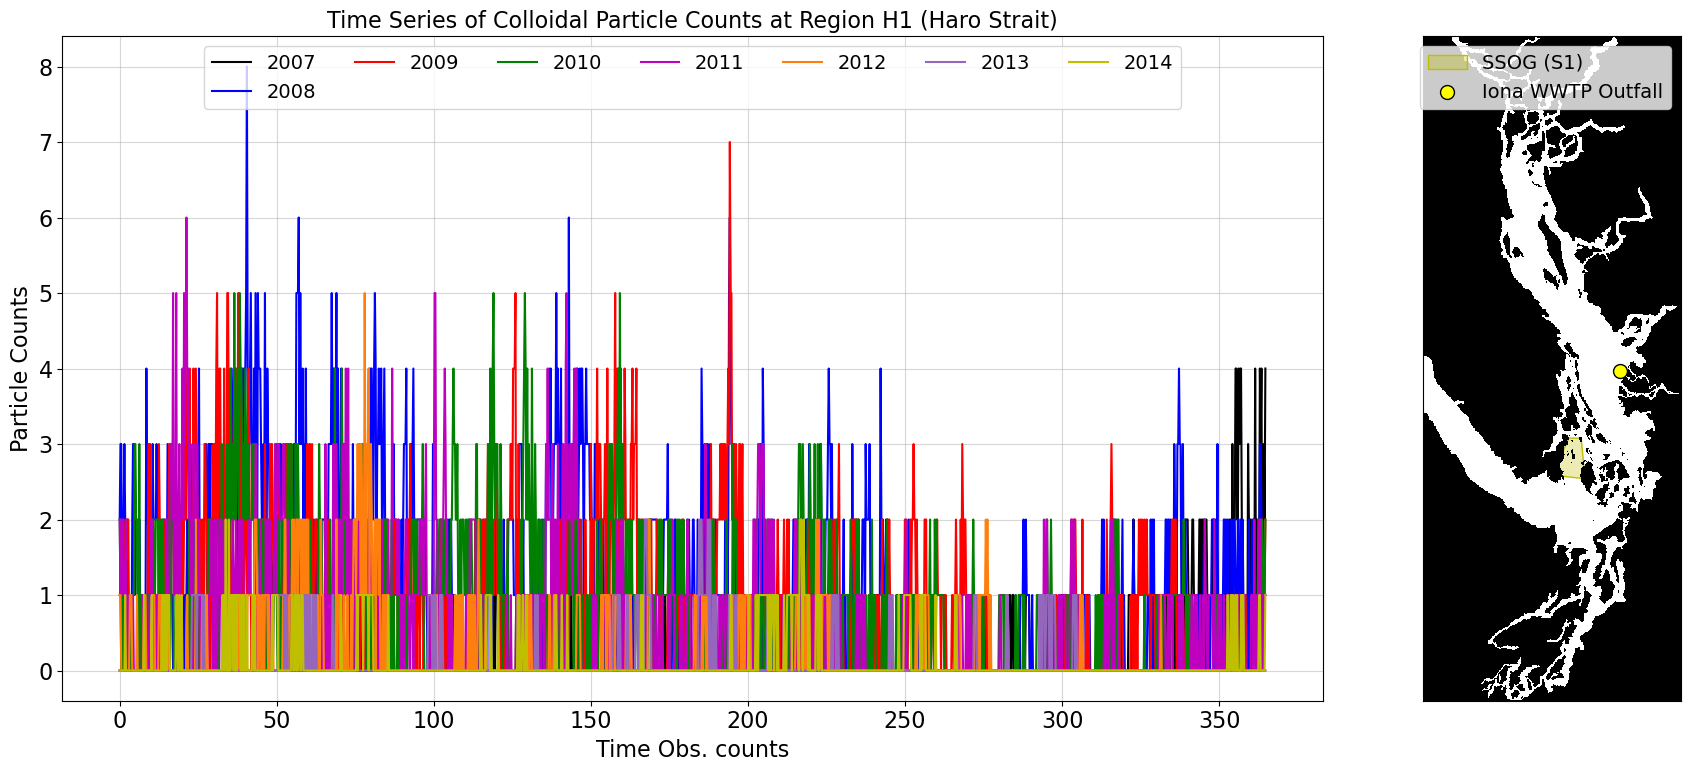

In [19]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(18, 8), gridspec_kw={'width_ratios': [3, 1]})

ax1.plot(time_days, tseries_y1_H['Total_Count'].values[::2], 'k', label='2007') 
ax1.plot(time_days, tseries_y2_H['Total_Count'].values[::2], 'b', label='2008') 
ax1.plot(time_days, tseries_y3_H['Total_Count'], 'r', label='2009') 
ax1.plot(time_days, tseries_y4_H['Total_Count'], 'g', label='2010') 
ax1.plot(time_days, tseries_y5_H['Total_Count'], 'm', label='2011') 
ax1.plot(time_days, tseries_y6_H['Total_Count'], 'tab:orange', label='2012') 
ax1.plot(time_days, tseries_y7_H['Total_Count'], 'tab:purple', label='2013') 
ax1.plot(time_days, tseries_y8_H['Total_Count'], 'y', label='2014') 


#ax1.xaxis.set_major_locator(mdates.YearLocator())
#ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
#ax1.xaxis.set_minor_locator(mdates.MonthLocator(interval=1)) 
ax1.grid(True, alpha=0.5)
ax1.legend(fontsize=14, loc = 'upper center', ncol = 7)
ax1.set_ylabel('Particle Counts')
ax1.set_title('Time Series of Colloidal Particle Counts at Region H1 (Haro Strait)', fontsize = 16)
ax1.set_xlabel('Time Obs. counts')
#
plot_polygon(polygon_H1, ax=ax2, color='y', label = 'SSOG (S1)',add_points=False)
#ax3.scatter(points_x_N2, points_y_N2, c = colors_regions[6],s = 20,  marker = 's')
#ax3.scatter(points_x_N3, points_y_N3, c = colors_regions[6],s = 20,  marker = 's')

ax2.pcolormesh(mask['tmask'][0][0], cmap = cmap)
## Source ##
source_lat = 49.195045
source_lon = -123.301956
s_y, s_x = finder2(source_lat, source_lon, mask)
s_y, s_x = finder2(source_lat, source_lon, mask)
##
ax2.scatter(s_x, s_y, color='yellow', edgecolor='black', s=100, zorder=5, label='Iona WWTP Outfall')
ax2.tick_params(which='both', bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False)
f = 1.14
ax2.set_aspect(f); ax2.legend(loc = 'upper right', fontsize = 14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# The entire system

In [14]:
def get_system_timeseries_optimized(filename, status_var='status', 
                                    target_status=2, chunk_size=500):
    """
    Computes a particle timeseries filtered by status across the entire system.
    Optimized for minimal memory usage and high execution speed via chunking.
    """
    with xr.open_dataset(filename) as data:
        n_obs = data.sizes['obs'] 
        counts_per_time = np.zeros(n_obs, dtype=int)
        
        for start in range(0, n_obs, chunk_size):
            end = min(start + chunk_size, n_obs)
            
            status_chunk = data[status_var].isel(obs=slice(start, end)).values
            
            if isinstance(target_status, (list, tuple, np.ndarray)):
                status_mask = np.isin(status_chunk, target_status)
            else:
                status_mask = (status_chunk == target_status)
            
            if not np.any(status_mask):
                continue
                

            chunk_time_indices = np.where(status_mask)[1]
            
            absolute_time_indices = chunk_time_indices + start
            
            counts_per_time += np.bincount(absolute_time_indices, minlength=n_obs)
                
    return pd.DataFrame({'Total_Count': counts_per_time})

In [15]:
tseries_all_y1 = get_system_timeseries_optimized(filename_y1)
tseries_all_y2 = get_system_timeseries_optimized(filename_y2)
tseries_all_y3 = get_system_timeseries_optimized(filename_y3)
tseries_all_y4 = get_system_timeseries_optimized(filename_y4)
tseries_all_y5 = get_system_timeseries_optimized(filename_y5)
tseries_all_y6 = get_system_timeseries_optimized(filename_y6)
tseries_all_y7 = get_system_timeseries_optimized(filename_y7)

In [16]:
#tseries_jdf_y1 = get_system_timeseries_optimized(filename_y1, target_status=[7,8])
#tseries_jdf_y2 = get_system_timeseries_optimized(filename_y2, target_status=[7,8])
#tseries_jdf_y3 = get_system_timeseries_optimized(filename_y3, target_status=[7,8])
#tseries_jdf_y4 = get_system_timeseries_optimized(filename_y4, target_status=[7,8])
#tseries_jdf_y5 = get_system_timeseries_optimized(filename_y5, target_status=[7,8])

In [17]:
#values_jdf_y1 = tseries_jdf_y1['Total_Count'].values[::2]
#values_jdf_y2 = values_jdf_y1 + tseries_jdf_y2['Total_Count'].values[::2]
#values_jdf_y3 = values_jdf_y2 + tseries_jdf_y3['Total_Count'].values
#values_jdf_y4 = values_jdf_y3 + tseries_jdf_y4['Total_Count'].values
#values_jdf_y5 = values_jdf_y4 + tseries_jdf_y5['Total_Count'].values

In [18]:
#all_jdf_timeseries = np.concatenate([values_jdf_y1, values_jdf_y2])#, values_jdf_y3, values_jdf_y4, values_jdf_y5])

In [19]:
values_all_y1 = tseries_all_y1['Total_Count'].values[::2]
values_all_y2 = values_all_y1 + tseries_all_y2['Total_Count'].values[::2]
values_all_y3 = values_all_y2 + tseries_all_y3['Total_Count'].values
values_all_y4 = values_all_y3 + tseries_all_y4['Total_Count'].values
values_all_y5 = values_all_y4 + tseries_all_y5['Total_Count'].values
values_all_y6 = values_all_y5 + tseries_all_y6['Total_Count'].values
values_all_y7 = values_all_y6 + tseries_all_y7['Total_Count'].values

In [20]:
all_system_timeseries = np.concatenate([values_all_y1, values_all_y2, values_all_y3, values_all_y4, values_all_y5, values_all_y6, values_all_y7])
time_6h = pd.date_range(start='2007-01-01', periods=1460*7, freq='6h')

Fitted Parameters:
Amplitude (a): -905669.85
Rate per day (b): -0.00007
Offset (c): 906392.92


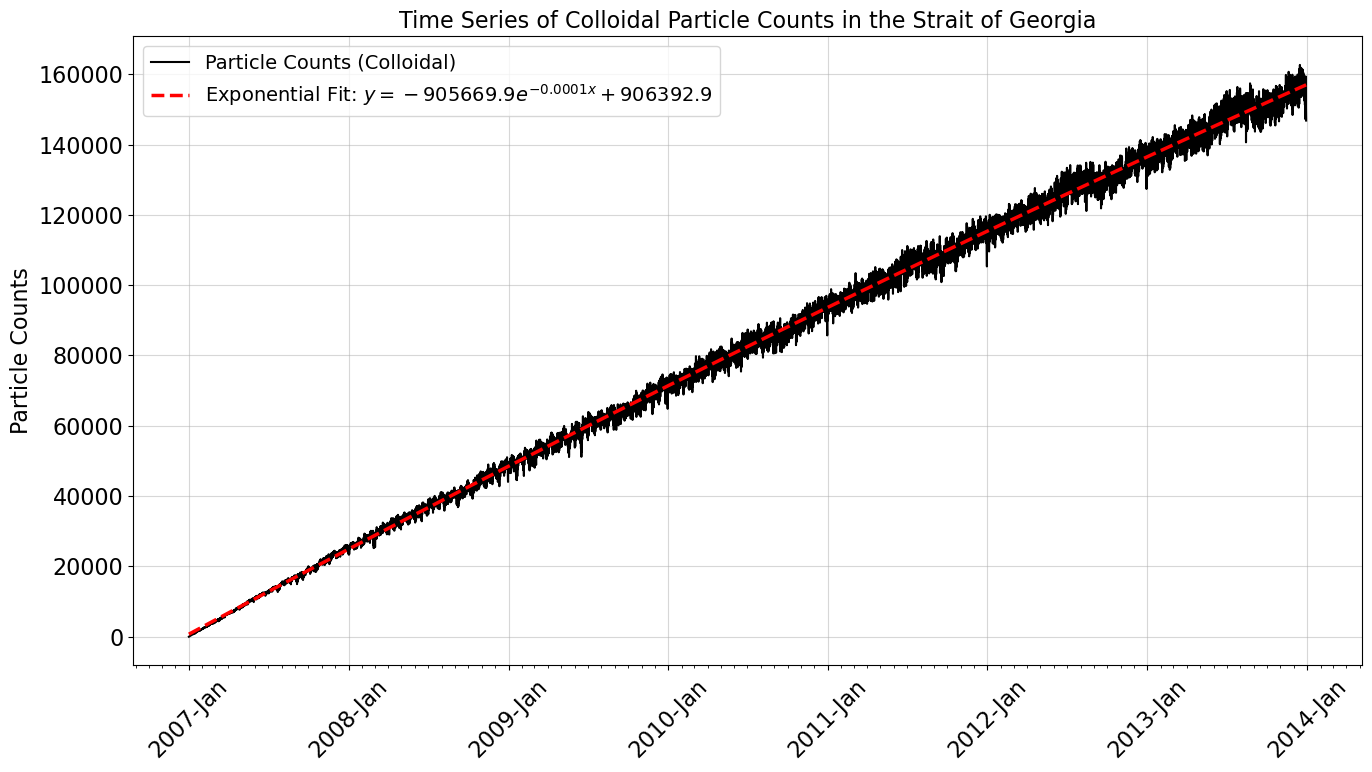

In [21]:
import matplotlib.dates as mdates
from scipy.optimize import curve_fit

def exponential_func(x, a, b, c):
    return a * np.exp(b * x) + c

x_days = np.arange(len(all_system_timeseries)) / 4.0

initial_guess = [np.max(all_system_timeseries) - np.min(all_system_timeseries), -0.01, np.min(all_system_timeseries)]

popt, pcov = curve_fit(exponential_func, x_days, all_system_timeseries, p0=initial_guess, maxfev=10000)

a_fit, b_fit, c_fit = popt
print(f"Fitted Parameters:")
print(f"Amplitude (a): {a_fit:.2f}")
print(f"Rate per day (b): {b_fit:.5f}")
print(f"Offset (c): {c_fit:.2f}")

fitted_curve = exponential_func(x_days, a_fit, b_fit, c_fit)

plt.rcParams.update({'font.size': 16})
colors = [(0, 0, 0, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)
fig, ax1 = plt.subplots(figsize=(14, 8))

ax1.plot(time_6h, all_system_timeseries, 'k', label='Particle Counts (Colloidal)') 
#ax1.plot(time_6h, all_jdf_timeseries, 'b', label = 'Flushed Out Particle Counts', linewidth = 3, alpha = .5) 


ax1.plot(time_6h, fitted_curve, 'r--', linewidth=2.5, 
        label=f'Exponential Fit: $y = {a_fit:.1f}e^{{{b_fit:.4f}x}} + {c_fit:.1f}$')
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
ax1.xaxis.set_minor_locator(mdates.MonthLocator(interval=1)) 
ax1.grid(True, alpha=0.5)
ax1.legend(fontsize=14, loc = 'upper left')
ax1.set_ylabel('Particle Counts')
ax1.set_title('Time Series of Colloidal Particle Counts in the Strait of Georgia', fontsize = 16)
#
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

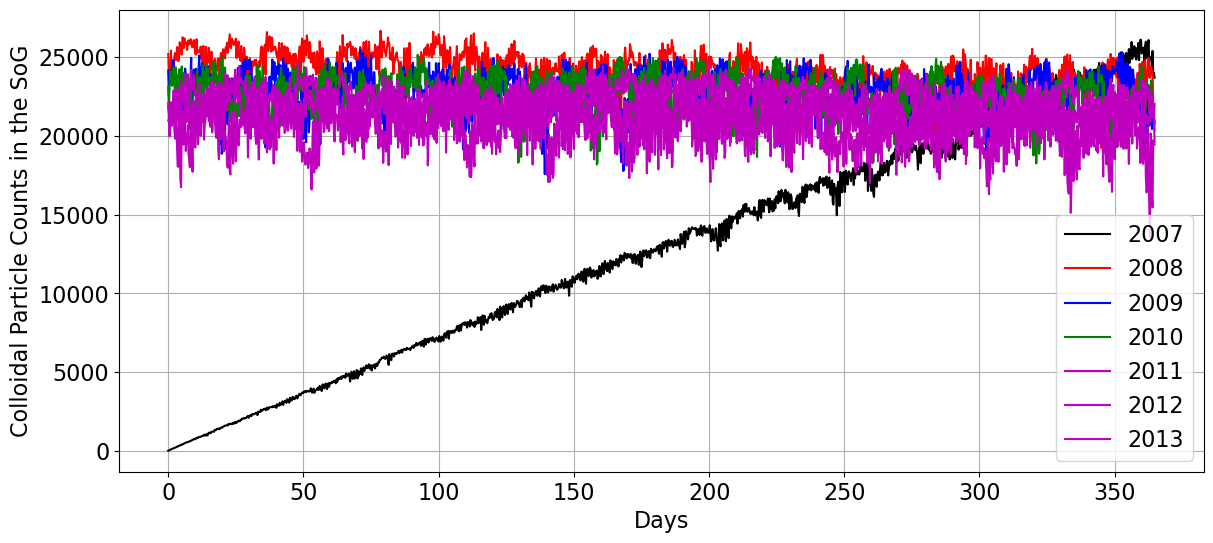

In [22]:
fig, ax = plt.subplots(figsize = (14,6))
ax.plot(time_days, tseries_all_y1['Total_Count'][::2].values, label = '2007', color = 'k')
ax.plot(time_days, tseries_all_y2['Total_Count'][::2].values, label = '2008', color = 'r')
ax.plot(time_days, tseries_all_y3['Total_Count'].values, label = '2009', color = 'b')
ax.plot(time_days, tseries_all_y4['Total_Count'].values, label = '2010', color = 'g')
ax.plot(time_days, tseries_all_y5['Total_Count'].values, label = '2011', color = 'm')
ax.plot(time_days, tseries_all_y6['Total_Count'].values, label = '2012', color = 'm')
ax.plot(time_days, tseries_all_y7['Total_Count'].values, label = '2013', color = 'm')


ax.legend(loc = 'lower right')
ax.set_ylabel('Colloidal Particle Counts in the SoG')
ax.set_xlabel('Days')
ax.grid()
#
#ax[1].bar(['Year 1', 'Year 2'], 
#          [tseries_all_y1['Total_Count'].sum(), tseries_all_y2['Total_Count'].sum()]
#           , color = ['k', 'r', 'b', 'g', 'm'])
#, tseries_all_y3['Total_Count'].sum(), 
           #tseries_all_y4['Total_Count'].sum(), tseries_all_y5['Total_Count'].sum()]
#ax[1].set_ylabel('Total Particles Sum per Year in the SoG')

In [27]:
tseries_all_y1_p = get_system_timeseries_optimized(filename_y1, target_status=[1,3])
tseries_all_y2_p = get_system_timeseries_optimized(filename_y2, target_status=[1,3])
#tseries_all_y3_p = get_system_timeseries_optimized(filename_y3, target_status=[1,3])
#tseries_all_y4_p = get_system_timeseries_optimized(filename_y4, target_status=[1,3])
#tseries_all_y5_p = get_system_timeseries_optimized(filename_y5, target_status=[1,3])

In [28]:
tseries_all_y1_sed = get_system_timeseries_optimized(filename_y1, target_status=[11,12,13])
tseries_all_y2_sed = get_system_timeseries_optimized(filename_y2, target_status=[11,12,13])
#tseries_all_y3_sed = get_system_timeseries_optimized(filename_y3, target_status=[11,12,13])
#tseries_all_y4_sed = get_system_timeseries_optimized(filename_y4, target_status=[11,12,13])
#tseries_all_y5_sed = get_system_timeseries_optimized(filename_y5, target_status=[11,12,13])

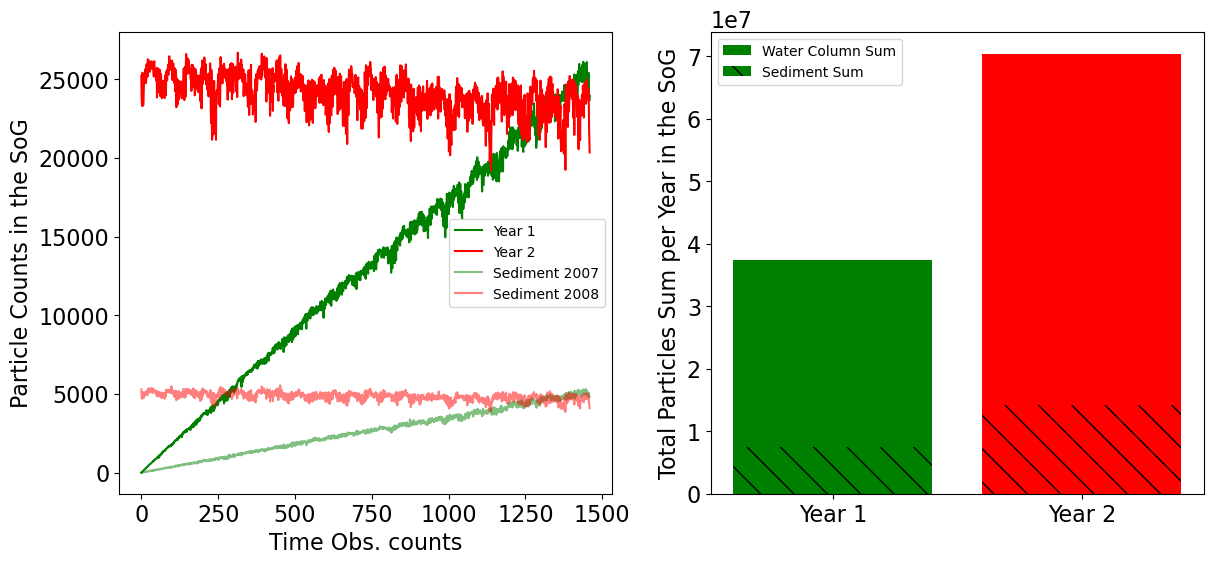

In [39]:
fig, ax = plt.subplots(1,2, figsize = (14,6))
ax[0].plot(tseries_all_y1['Total_Count'][::2].values, label = 'Year 1', color = 'g')
ax[0].plot(tseries_all_y2['Total_Count'][::2].values, label = 'Year 2', color = 'r')
#ax[0].plot(tseries_all_y3['Total_Count'].values, label = 'Year 3', color = 'b')
#ax[0].plot(tseries_all_y4['Total_Count'].values, label = 'Year 4', color = 'g')
#ax[0].plot(tseries_all_y5['Total_Count'].values, label = 'Year 5', color = 'm')
#
ax[0].plot(tseries_all_y1_p['Total_Count'][::2].values, color = 'g', alpha = .5, label = 'Sediment 2007')
ax[0].plot(tseries_all_y2_p['Total_Count'][::2].values, color = 'r', alpha = .5, label = 'Sediment 2008')
#ax[0].plot(tseries_all_y3_p['Total_Count'].values, color = 'b', alpha = .5)
#ax[0].plot(tseries_all_y4_p['Total_Count'].values, color = 'g', alpha = .5)
#ax[0].plot(tseries_all_y5_p['Total_Count'].values, color = 'm', alpha = .5)
ax[0].set_xlabel('Time Obs. counts')

#
ax[0].legend(loc = 'center right', fontsize = 10)
ax[0].set_ylabel('Particle Counts in the SoG')
#
ax[1].bar(['Year 1', 'Year 2'], 
          [tseries_all_y1['Total_Count'].sum(), tseries_all_y2['Total_Count'].sum()], color = ['g', 'r'], label = 'Water Column Sum')
           #tseries_all_y3['Total_Count'].sum(), tseries_all_y4['Total_Count'].sum(), tseries_all_y5['Total_Count'].sum()]
ax[1].bar(['Year 1', 'Year 2'], 
          [tseries_all_y1_p['Total_Count'].sum(), tseries_all_y2_p['Total_Count'].sum()]
          , color = ['g', 'r'], hatch = '\\', label = 'Sediment Sum')
           # tseries_all_y3_p['Total_Count'].sum(), tseries_all_y4_p['Total_Count'].sum(), tseries_all_y5_p['Total_Count'].sum()]
ax[1].set_ylabel('Total Particles Sum per Year in the SoG')
ax[1].legend(loc = 'upper left', fontsize = 10)

Text(0, 0.5, 'Total Particles Sum per Year in the SoG')

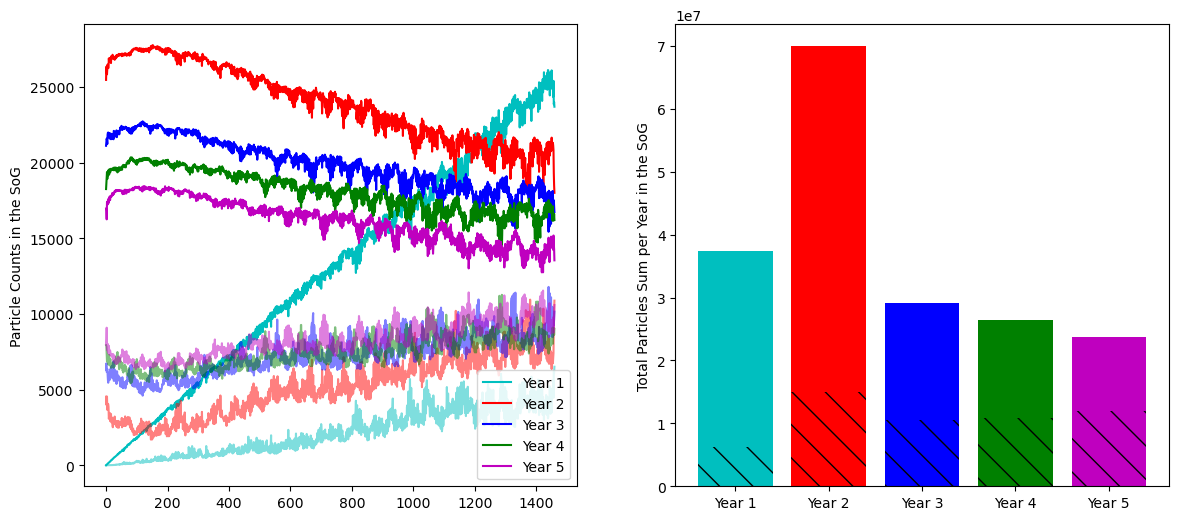

In [12]:
fig, ax = plt.subplots(1,2, figsize = (14,6))
ax[0].plot(tseries_all_y1['Total_Count'][::2].values, label = 'Year 1', color = 'c')
ax[0].plot(tseries_all_y2['Total_Count'][::2].values, label = 'Year 2', color = 'r')
ax[0].plot(tseries_all_y3['Total_Count'].values, label = 'Year 3', color = 'b')
ax[0].plot(tseries_all_y4['Total_Count'].values, label = 'Year 4', color = 'g')
ax[0].plot(tseries_all_y5['Total_Count'].values, label = 'Year 5', color = 'm')
#
ax[0].plot(tseries_all_y1_sed['Total_Count'][::2].values, color = 'c', alpha = .5)
ax[0].plot(tseries_all_y2_sed['Total_Count'][::2].values, color = 'r', alpha = .5)
ax[0].plot(tseries_all_y3_sed['Total_Count'].values, color = 'b', alpha = .5)
ax[0].plot(tseries_all_y4_sed['Total_Count'].values, color = 'g', alpha = .5)
ax[0].plot(tseries_all_y5_sed['Total_Count'].values, color = 'm', alpha = .5)
#
ax[0].legend(loc = 'lower right')
ax[0].set_ylabel('Particle Counts in the SoG')
#
ax[1].bar(['Year 1', 'Year 2', 'Year 3', 'Year 4', 'Year 5'], 
          [tseries_all_y1['Total_Count'].sum(), tseries_all_y2['Total_Count'].sum(), tseries_all_y3['Total_Count'].sum(), 
           tseries_all_y4['Total_Count'].sum(), tseries_all_y5['Total_Count'].sum()], color = ['c', 'r', 'b', 'g', 'm'])
ax[1].bar(['Year 1', 'Year 2', 'Year 3', 'Year 4', 'Year 5'], 
          [tseries_all_y1_sed['Total_Count'].sum(), tseries_all_y2_sed['Total_Count'].sum(), tseries_all_y3_sed['Total_Count'].sum(), 
           tseries_all_y4_sed['Total_Count'].sum(), tseries_all_y5_sed['Total_Count'].sum()], color = ['c', 'r', 'b', 'g', 'm'], hatch = '\\')
ax[1].set_ylabel('Total Particles Sum per Year in the SoG')

Resuspension event in January seems to be responsible for the strange peaks at the beginning of each year